# Лабораторная работа по теме: «Линейные классификаторы»

### Задание

Построить линейную дискриминантную функцию Фишера для классификации на два класса. Разбивку на классы сделать  по столбцу "правильных ответов". Если этот столбец непонятно как определить, то использовать  разбиение на 2 кластера в задании 2 или 3. Классификацию проводить по всем признакам, а для визуализации использовать два наиболее значимых или главные компоненты из задания 3. В этом задании не использовать готовые функции дискриминантного анализа из библиотек языка Пайтона (вспомогательные функции использовать можно и нужно). Обязательно нужна оценка качества классификации (accuracy, precision, recall, F1). Для оценки качества нужно использовать при обучении только часть размеченных данных, а остальные использовать для тестирования.

### Подключение необходимых библиотек и загрузка датасета данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

df = pd.read_csv('/content/adult.csv')
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Предобработка данных

In [ ]:
columns_for_clustering = [
    'age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week',
    'workclass', 'education', 'marital-status', 'occupation',
    'relationship', 'race', 'sex', 'native-country'
]
df = df[columns_for_clustering + ['salary']]
df = df.replace(' ?', np.nan).dropna().reset_index(drop=True)
print(f"Размер данных после очистки: {df.shape}")

# Кодирование категориальных признаков
categorical_cols = ['workclass', 'education', 'marital-status', 'occupation',
                    'relationship', 'race', 'sex', 'native-country']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Матрица признаков
X = df[columns_for_clustering].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Предобработка данных завершена")

Размер данных после очистки: (32561, 14)
Предобработка данных завершена


### Получение целевой переменной

In [ ]:
# Применяем PCA (2 компоненты) и KMeans (2 кластера)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

kmeans_pca = KMeans(n_clusters=2, random_state=42, n_init=10)
y = kmeans_pca.fit_predict(X_pca)

print("   Распределение кластеров:")
print(pd.Series(y).value_counts())
df['Cluster'] = y

   Распределение кластеров:
1    18586
0    13975
Name: count, dtype: int64


### Реализация линейного дискриминанта Фишера

In [ ]:
class FisherLDA:
    def __init__(self):
        self.w = None          # Вектор весов
        self.threshold = None  # Порог
        self.mean0 = None
        self.mean1 = None

    def fit(self, X, y):
        X0 = X[y == 0]
        X1 = X[y == 1]

        self.mean0 = np.mean(X0, axis=0)
        self.mean1 = np.mean(X1, axis=0)

        # Внутриклассовая матрица рассеяния
        Sw = np.zeros((X.shape[1], X.shape[1]))
        for x in X0:
            diff = x - self.mean0
            Sw += np.outer(diff, diff)
        for x in X1:
            diff = x - self.mean1
            Sw += np.outer(diff, diff)

        # Решение через псевдообратную матрицу
        diff_means = self.mean1 - self.mean0
        self.w = np.linalg.pinv(Sw).dot(diff_means)

        # Порог (середина между проекциями средних)
        proj0 = self.w.dot(self.mean0)
        proj1 = self.w.dot(self.mean1)
        self.threshold = (proj0 + proj1) / 2
        return self

    # Предсказание класса для каждого образца
    def predict(self, X):
        projections = X.dot(self.w)
        return (projections >= self.threshold).astype(int)

### Разделение данных на обучающую и тестовую выборки

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

Размер обучающей выборки: 22792
Размер тестовой выборки: 9769


### Обучение LDA и предсказание

In [ ]:
lda = FisherLDA()
lda.fit(X_train, y_train)
y_pred = lda.predict(X_test)

### Оценка качества классификации

In [ ]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nОценка качества на тестовой выборке:")
print(f"   Accuracy:  {acc:.4f}")
print(f"   Precision: {prec:.4f}")
print(f"   Recall:    {rec:.4f}")
print(f"   F1-score:  {f1:.4f}")


Оценка качества на тестовой выборке:
   Accuracy:  0.9671
   Precision: 0.9630
   Recall:    0.9801
   F1-score:  0.9715


### Визуализация с использованием главных компонент

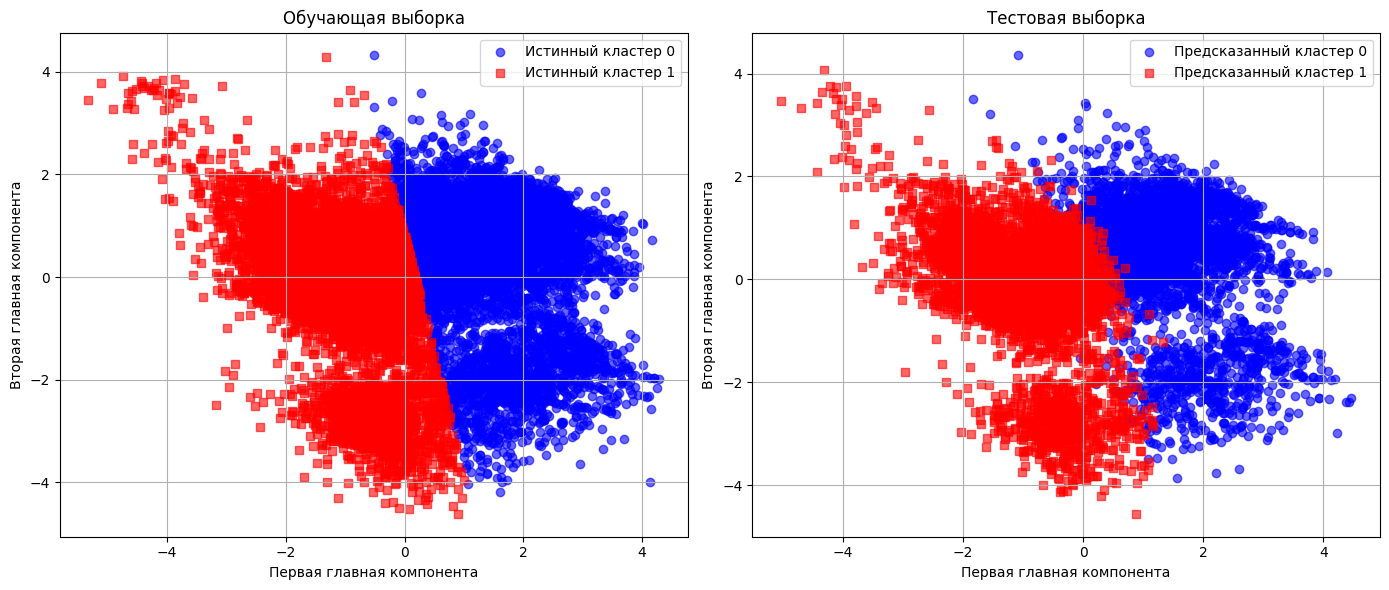

In [ ]:
# Разделим на обучающие и тестовые точки
indices_train = np.arange(len(X_scaled))[:len(X_train)]
indices_test  = np.arange(len(X_scaled))[len(X_train):]
X_train_pca = X_pca[indices_train]
X_test_pca  = X_pca[indices_test]

# Предсказания LDA для визуализации
y_pred_all = lda.predict(X_scaled)

colors = {0: 'blue', 1: 'red'}
markers = {0: 'o', 1: 's'}
plt.figure(figsize=(14, 6))

# Первый график - обучающие точки, истинные кластеры (целевая переменная)
plt.subplot(1, 2, 1)
for class_id in [0, 1]:
    idx = (y == class_id) & (np.arange(len(y)) < len(X_train))
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1],
                c=colors[class_id], marker=markers[class_id],
                label=f'Истинный кластер {class_id}', alpha=0.6)
plt.title('Обучающая выборка')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.legend()
plt.grid(True)

# Второй график - тестовые точки, предсказанные LDA
plt.subplot(1, 2, 2)
for class_id in [0, 1]:
    idx = (y_pred_all == class_id) & (np.arange(len(y)) >= len(X_train))
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1],
                c=colors[class_id], marker=markers[class_id],
                label=f'Предсказанный кластер {class_id}', alpha=0.6)
plt.title('Тестовая выборка')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Проекция на направление Фишера

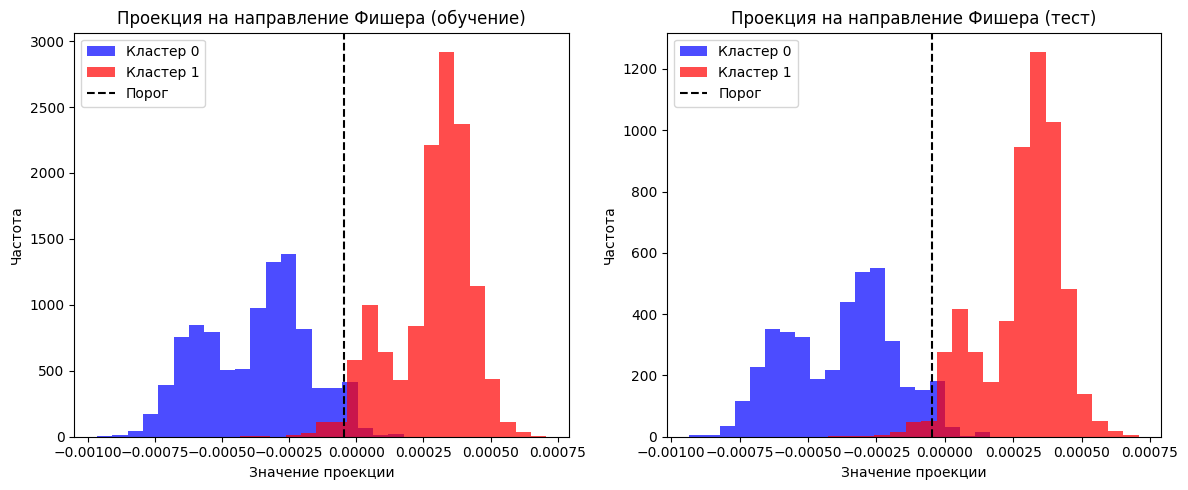

In [ ]:
proj_train = X_train.dot(lda.w)
proj_test  = X_test.dot(lda.w)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(proj_train[y_train == 0], bins=20, alpha=0.7, label='Кластер 0', color='blue')
plt.hist(proj_train[y_train == 1], bins=20, alpha=0.7, label='Кластер 1', color='red')
plt.axvline(lda.threshold, color='black', linestyle='--', label='Порог')
plt.title('Проекция на направление Фишера (обучение)')
plt.xlabel('Значение проекции')
plt.ylabel('Частота')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(proj_test[y_test == 0], bins=20, alpha=0.7, label='Кластер 0', color='blue')
plt.hist(proj_test[y_test == 1], bins=20, alpha=0.7, label='Кластер 1', color='red')
plt.axvline(lda.threshold, color='black', linestyle='--', label='Порог')
plt.title('Проекция на направление Фишера (тест)')
plt.xlabel('Значение проекции')
plt.ylabel('Частота')
plt.legend()
plt.tight_layout()
plt.show()

### Вывод
Выполняя лабораторную работу, была построена линейная дискриминантная функция Фишера для классификации на два класса. Метрики показали высокую эффективность классификатора: accuracy - 96.71%, precision — 96.30%, recall — 98.01%, F1-score — 97.15%, что свидетельствует о хорошей способности модели правильно идентифицировать объекты обоих классов.